In [1]:
import os
import sys
sys.path.append('/home/royhirsch/conformal/v3')

from ml_collections import config_dict
import logging
import pandas as pd
import pickle
import torch
import torch.nn as nn
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.special import softmax
import torchcp
from data_config import get_config

In [2]:
config = get_config('cifar100_resnet56')
config.par_calib = 0.5
config.num_calib = int(config.num_samples * config.par_calib)
config.plat_scale = True
config.seed = 42
config.estimation_method_name = 'max' # max / mean
config.randomized = True
config.no_zero_size_sets = True
config.alpha = 0.05

# Funcs

In [3]:
import torch.optim as optim
from tqdm import tqdm


def platt_scale(logits, labels, max_iters=100, lr=0.01, epsilon=0.005):
    dataset = torch.utils.data.TensorDataset(torch.from_numpy(logits),
                                             torch.from_numpy(labels).long()) 
    dataloader = torch.utils.data.DataLoader(dataset,
                                             batch_size=64,
                                             shuffle=True)

    nll_criterion = nn.CrossEntropyLoss().cuda()

    T = nn.Parameter(torch.Tensor([1.]).cuda())
    optimizer = optim.SGD([T], lr=lr)
    for iter in tqdm(range(max_iters)):
        T_old = T.item()
        for x, targets in dataloader:
            optimizer.zero_grad()
            x = x.cuda()
            x.requires_grad = True
            out = x/T
            loss = nll_criterion(out, targets.long().cuda())
            loss.backward()
            optimizer.step()
        if abs(T_old - T.item()) < epsilon:
            break
    return T.item() 


if config.dataset_name != 'imnet1k_r152':
    with open(config.file_name, 'rb') as file:
        data = pickle.load(file)

    labels_eval, labels_calib, scores_eval, scores_calib = train_test_split(
        data["labels"], data["preds"], test_size=config.par_calib, random_state=42
    )
    if config.plat_scale:
        t = platt_scale(scores_calib, labels_calib, max_iters=100, lr=0.01, epsilon=0.005)
    else:
        t = 1.0

    print(f"Temperature: {t}")
    scores_calib = softmax(scores_calib / t, axis=1)
    scores_eval = softmax(scores_eval / t, axis=1)
        
else:    
    data = np.load('/home/royhirsch/conformal/data/imagenet/imagenet-resnet152.npz')
    smx = data["smx"]
    labels = data["labels"].astype(int)

    idx = np.array([1] * config.num_calib + [0] * (smx.shape[0] - config.num_calib)) > 0
    np.random.shuffle(idx)
    scores_calib, scores_eval = smx[idx, :], smx[~idx, :]
    labels_calib, labels_eval = labels[idx], labels[~idx]

eval_data = {"labels": labels_eval, "scores": scores_eval}
calib_data = {"labels": labels_calib, "scores": scores_calib}


  9%|▉         | 9/100 [00:00<00:09,  9.30it/s]

Temperature: 1.734318494796753


In [4]:
def calc_aps_scores(scores, labels, randomized=True, seed=config.seed):
    cal_pi = scores.argsort(1)[:, ::-1]
    cal_srt = np.take_along_axis(scores, cal_pi, axis=1).cumsum(axis=1)
    cal_softmax_correct_class = np.take_along_axis(cal_srt, cal_pi.argsort(axis=1), axis=1)[
        range(len(labels)), labels
    ]
    if not randomized:
        cal_scores = cal_softmax_correct_class
    else:
        np.random.seed(seed)
        cumsum_index = np.where(cal_srt == cal_softmax_correct_class[:,None])[1]
        if cumsum_index.shape[0] != cal_srt.shape[0]:
            _, unique_indices = np.unique(np.where(
                cal_srt == cal_softmax_correct_class[:,None])[0], return_index=True)
            cumsum_index = cumsum_index[unique_indices]
        high = cal_softmax_correct_class
        low = np.zeros_like(high)
        low[cumsum_index != 0] = cal_srt[np.where(cumsum_index != 0)[0], cumsum_index[cumsum_index != 0]-1]
        cal_scores = np.random.uniform(low=low, high=high)
    return cal_scores


def get_aps_sets(scores, qhat, randomized=True, no_zero_size_sets=True, seed=config.seed):
    val_pi = scores.argsort(1)[:, ::-1]
    val_srt = np.take_along_axis(scores, val_pi, axis=1).cumsum(axis=1)
    if qhat.ndim:
        qhat = np.expand_dims(qhat, 1)
    if not randomized:
        prediction_sets = np.take_along_axis(val_srt <= qhat, val_pi.argsort(axis=1), axis=1)
    else:
        np.random.seed(seed)
        n_val = val_srt.shape[0]
        cumsum_index = np.sum(val_srt <= qhat, axis=1)
        cumsum_index[cumsum_index == scores.shape[-1]] = scores.shape[-1] - 1
        high = val_srt[np.arange(n_val), cumsum_index]
        low = np.zeros_like(high)
        low[cumsum_index > 0] = val_srt[np.arange(n_val), cumsum_index-1][cumsum_index > 0]
        prob = (qhat.squeeze() - low)/(high - low + 1e-10)
        prob = np.nan_to_num(prob, nan=0.0)
        prob = np.clip(prob, 0, 1)
        rv = np.random.binomial(1,prob,size=(n_val))
        randomized_threshold = low
        randomized_threshold[rv == 1] = high[rv == 1]
        if no_zero_size_sets:
            randomized_threshold = np.maximum(randomized_threshold, val_srt[:,0])
        prediction_sets = np.take_along_axis(val_srt <= randomized_threshold[:,None], val_pi.argsort(axis=1), axis=1)
    return prediction_sets


# Baselines APS

In [5]:
n = len(calib_data["labels"])

cal_scores = calc_aps_scores(calib_data["scores"], calib_data["labels"], config.randomized)
baseline_qhat = np.quantile(
    cal_scores, np.ceil((n + 1) * (1 - config.alpha)) / n, interpolation="higher"
)
prediction_sets = get_aps_sets(eval_data["scores"], baseline_qhat, config.randomized, config.no_zero_size_sets)

empirical_coverage = prediction_sets[
    np.arange(prediction_sets.shape[0]), eval_data["labels"]
].mean()

baseline_mets = {
    "size": prediction_sets.sum(1).mean(),
    "coverage": empirical_coverage,
}

print('Baseline mets:')
for key, value in baseline_mets.items():
    print(f"{key}: {value:.4f}")
print('Qhat: {:.4f}'.format(baseline_qhat))


Baseline mets:
size: 10.9112
coverage: 0.9596
Qhat: 0.9547


In [6]:
# two groups baseline
above_calib_inds = np.where(calib_data['scores'].max(1) > 1. - config.alpha)[0]
below_calib_inds = np.where(calib_data['scores'].max(1) <= 1. - config.alpha)[0]
print(len(above_calib_inds), len(below_calib_inds))

above_valid_inds = np.where(eval_data['scores'].max(1) > 1. - config.alpha)[0]
below_valid_inds = np.where(eval_data['scores'].max(1) <= 1. - config.alpha)[0]

baseline_qhat_above = np.quantile(
    calc_aps_scores(calib_data['scores'][above_calib_inds, :], calib_data['labels'][above_calib_inds], config.randomized),
    np.ceil((n + 1) * (1 - config.alpha)) / n, interpolation="higher"
)

baseline_qhat_below = np.quantile(
    calc_aps_scores(calib_data['scores'][below_calib_inds, :], calib_data['labels'][below_calib_inds], config.randomized),
    np.ceil((n + 1) * (1 - config.alpha)) / n, interpolation="higher"
)


prediction_sets_above = get_aps_sets(eval_data["scores"][above_valid_inds, :], baseline_qhat_above, config.randomized, config.no_zero_size_sets)
prediction_sets_below = get_aps_sets(eval_data["scores"][below_valid_inds, :], baseline_qhat_below, config.randomized, config.no_zero_size_sets)

empirical_coverage_baseline_groups = np.concatenate([
    prediction_sets_above[np.arange(prediction_sets_above.shape[0]), eval_data['labels'][above_valid_inds]],
    prediction_sets_below[np.arange(prediction_sets_below.shape[0]), eval_data['labels'][below_valid_inds]],
]).mean()

mean_size_baseline_groups = np.concatenate([prediction_sets_above, prediction_sets_below]).sum(1).mean()

print('Two groups baseline mets:')
print('Size: {:.2f}'.format(mean_size_baseline_groups))
print('Coverage: {:.4f}'.format(empirical_coverage_baseline_groups))    

baseline_groups_mets = {
    "size": mean_size_baseline_groups,
    "coverage": empirical_coverage_baseline_groups,
}


1676 3324
Two groups baseline mets:
Size: 10.63
Coverage: 0.9596


# Ours method

In [7]:
def get_estimated_score(scores, method, randomized=True, seed=config.seed):
    if method == 'max':
        return calc_aps_scores(scores, scores.argmax(1), randomized, seed)
    elif method == 'mean':
        cal_pi = scores.argsort(1)[:, ::-1]
        cal_srt = np.take_along_axis(scores, cal_pi, axis=1).cumsum(axis=1)
        cal_softmax_correct_class = np.take_along_axis(cal_srt, cal_pi.argsort(axis=1), axis=1)
        return (cal_softmax_correct_class * scores).sum(1)
    else:
        raise ValueError('Unknown method')


In [8]:
cal_scores_est = get_estimated_score(calib_data["scores"], method=config.estimation_method_name, randomized=config.randomized, seed=config.seed)
cal_scores_true = calc_aps_scores(calib_data["scores"], calib_data["labels"], randomized=config.randomized)
# cal_scores_est = np.zeros_like(cal_scores_est)
normalizer = cal_scores_true.max()
eps = 1e-10
residuales = (cal_scores_true - cal_scores_est)  / (normalizer - cal_scores_est + eps)

print('Residuales: mean: {:.3f} std: {:.3f} min: {:.3f} max: {:.3f}'.format(residuales.mean(), residuales.std(), residuales.min(), residuales.max()))

qhat = np.quantile(
    residuales, np.ceil((n + 1) * (1 - config.alpha)) / n, interpolation="higher"
)

print('Qhat: {:.4f}'.format(qhat))
val_scores_est = get_estimated_score(eval_data["scores"], method=config.estimation_method_name, randomized=config.randomized, seed=config.seed)
val_scores_est_copy = val_scores_est
val_scores_true = calc_aps_scores(eval_data["scores"], eval_data["labels"], config.randomized)
# val_scores_est = np.zeros_like(val_scores_est)
val_scores_est = val_scores_est + qhat * (normalizer - val_scores_est + eps)
print('Par of scores above 1: {:.2f}'.format(np.sum(val_scores_est > 1) / len(val_scores_est)))
val_scores_est[val_scores_est > 1] = baseline_qhat
prediction_sets = get_aps_sets(eval_data["scores"], val_scores_est, config.randomized, config.no_zero_size_sets)

empirical_coverage = prediction_sets[
    np.arange(prediction_sets.shape[0]), eval_data["labels"]
].mean()

ours_mets = {
    "size": prediction_sets.sum(1).mean(),
    "coverage": empirical_coverage,
}

print('Ours mets:')
for key, value in ours_mets.items():
    print(f"{key}: {value:.4f}")


Residuales: mean: 0.188 std: 0.323 min: 0.000 max: 1.000
Qhat: 0.9016
Par of scores above 1: 0.00
Ours mets:
size: 8.3052
coverage: 0.9474


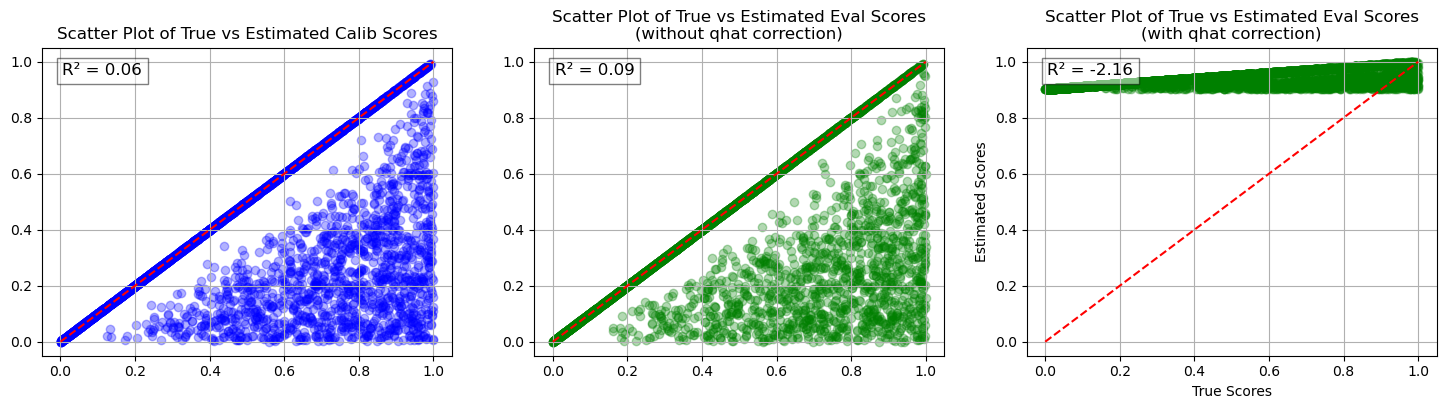

Text(0.5, 1.0, 'Estimated eval scores')

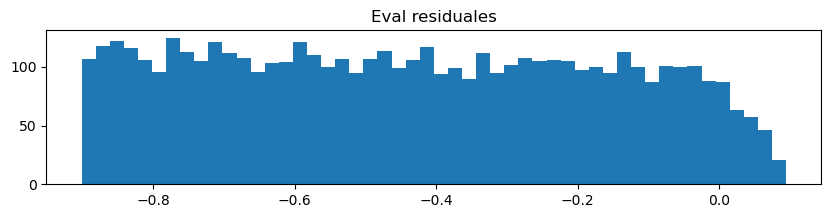

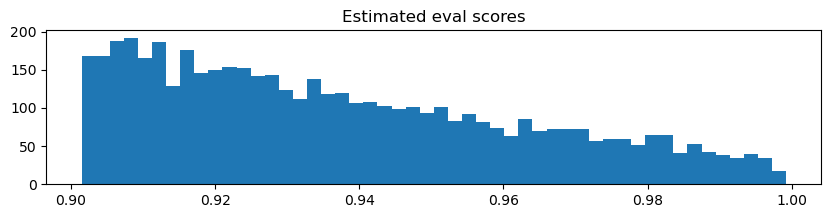

In [9]:
# debug #
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

fig, ax = plt.subplots(1, 3, figsize=(18, 4))

ax[0].scatter(cal_scores_true, cal_scores_est, color='blue', alpha=0.3)
ax[0].set_title('Scatter Plot of True vs Estimated Calib Scores')
r2 = r2_score(cal_scores_true, cal_scores_est)
ax[0].text(0.05, 0.95, f'R² = {r2:.2f}', transform=ax[0].transAxes, 
         fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
plt.xlabel('True Scores')
plt.ylabel('Estimated Scores')
ax[0].plot([0, 1], [0, 1], 'r--')
ax[0].grid(True)

ax[1].scatter(val_scores_true, val_scores_est_copy, color='green', alpha=0.3)
ax[1].set_title('Scatter Plot of True vs Estimated Eval Scores\n(without qhat correction)')
r2 = r2_score(val_scores_true, val_scores_est_copy)
ax[1].text(0.05, 0.95, f'R² = {r2:.2f}', transform=ax[1].transAxes, 
         fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
plt.xlabel('True Scores')
plt.ylabel('Estimated Scores')
ax[1].plot([0, 1], [0, 1], 'r--')
ax[1].grid(True)

ax[2].scatter(val_scores_true, val_scores_est, color='green', alpha=0.3)
ax[2].set_title('Scatter Plot of True vs Estimated Eval Scores\n(with qhat correction)')
r2 = r2_score(val_scores_true, val_scores_est)
ax[2].text(0.05, 0.95, f'R² = {r2:.2f}', transform=ax[2].transAxes, 
         fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
plt.xlabel('True Scores')
plt.ylabel('Estimated Scores')
ax[2].plot([0, 1], [0, 1], 'r--')
ax[2].grid(True)
plt.show()

plt.figure(figsize=(10, 2))
_ = plt.hist(val_scores_true - val_scores_est, bins=50)
plt.title('Eval residuales')

plt.figure(figsize=(10, 2))
_ = plt.hist(val_scores_est, bins=50)
plt.title('Estimated eval scores')

# Ours 2 groups

In [10]:
above_calib_inds = np.where(calib_data['scores'].max(1) > 1. - config.alpha)[0]
below_calib_inds = np.where(calib_data['scores'].max(1) <= 1. - config.alpha)[0]
print(len(above_calib_inds), len(below_calib_inds))

eps = 1e-10
cal_scores_above_est = calc_aps_scores(calib_data['scores'][above_calib_inds, :], calib_data['scores'].argmax(1)[above_calib_inds], config.randomized)
cal_max_score_above = calib_data['scores'][above_calib_inds, :].max()
cal_scores_above_true = calc_aps_scores(calib_data['scores'][above_calib_inds, :], calib_data['labels'][above_calib_inds], config.randomized) 
residuales_above = (cal_scores_above_true - cal_scores_above_est) / (cal_max_score_above - cal_scores_above_est + eps)
print('ABOVE')
print('Residuales: mean: {:.3f} std: {:.3f} min: {:.3f} max: {:.3f}'.format(
    residuales_above.mean(), residuales_above.std(), residuales_above.min(), residuales_above.max()))

qhat_above = np.quantile(
    residuales_above, np.ceil((n + 1) * (1 - config.alpha)) / n, interpolation="higher"
)
print('Qhat: {:.4f}'.format(qhat_above))

cal_scores_below_est = calc_aps_scores(calib_data['scores'][below_calib_inds, :], calib_data['scores'].argmax(1)[below_calib_inds], config.randomized)
cal_max_score_below = calib_data['scores'][below_calib_inds, :].max()
cal_scores_below_true = calc_aps_scores(calib_data['scores'][below_calib_inds, :], calib_data['labels'][below_calib_inds], config.randomized)
residuales_below = (cal_scores_below_true - cal_scores_below_est) / (cal_max_score_below - cal_scores_below_est + eps)
print('BELOW')
print('Residuales: mean: {:.3f} std: {:.3f} min: {:.3f} max: {:.3f}'.format(
    residuales_below.mean(), residuales_below.std(), residuales_below.min(), residuales_below.max()))

qhat_below = np.quantile(
    residuales_below, np.ceil((n + 1) * (1 - config.alpha)) / n, interpolation="higher"
)
print('Qhat: {:.4f}'.format(qhat_below))


1676 3324
ABOVE
Residuales: mean: 0.019 std: 0.132 min: 0.000 max: 1.000
Qhat: 0.0000
BELOW
Residuales: mean: 0.297 std: 0.390 min: 0.000 max: 3.248
Qhat: 1.0050


In [11]:
above_val_inds = np.where(eval_data['scores'].max(1) > 1. - config.alpha)[0]
below_val_inds = np.where(eval_data['scores'].max(1) <= 1. - config.alpha)[0]
print(len(above_val_inds), len(below_val_inds))

val_scores_above_est = calc_aps_scores(eval_data['scores'][above_val_inds, :], eval_data['scores'][above_val_inds, :].argmax(1), config.randomized)
val_scores_above_est = val_scores_above_est + qhat_above * (cal_max_score_above - val_scores_above_est + eps)
print('Par of scores above 1 (above fold): {:.2f} ({:.2f})'.format(
    np.sum(val_scores_above_est > 1) / len(val_scores_above_est),
    (np.sum(val_scores_above_est > 1) / len(val_scores_above_est)) * len(val_scores_above_est) / len(eval_data['labels'])))
val_scores_above_est[val_scores_above_est > 1] = baseline_qhat
prediction_sets_above = get_aps_sets(eval_data['scores'][above_val_inds, :], val_scores_above_est, config.randomized, config.no_zero_size_sets)

val_scores_below_est = calc_aps_scores(eval_data['scores'][below_val_inds, :], eval_data['scores'][below_val_inds, :].argmax(1), config.randomized)
val_scores_below_est = val_scores_below_est + qhat_below  * (cal_max_score_below - val_scores_below_est + eps)
print('Par of scores above 1 (below fold): {:.2f} ({:.2f})'.format(
    np.sum(val_scores_below_est > 1) / len(val_scores_below_est),
    (np.sum(val_scores_below_est > 1) / len(val_scores_below_est)) * len(val_scores_below_est) / len(eval_data['labels'])))
val_scores_below_est[val_scores_below_est > 1] = baseline_qhat
prediction_sets_below = get_aps_sets(eval_data['scores'][below_val_inds, :], val_scores_below_est, config.randomized, config.no_zero_size_sets)

empirical_coverage = np.concatenate([
    prediction_sets_above[np.arange(prediction_sets_above.shape[0]), eval_data['labels'][above_val_inds]],
    prediction_sets_below[np.arange(prediction_sets_below.shape[0]), eval_data['labels'][below_val_inds]],
]).mean()

ours_two_groups_mets = {
    "size": np.concatenate([
        prediction_sets_above,
        prediction_sets_below,
        ]).sum(1).mean(),
    "coverage": empirical_coverage,
}

print('Ours two groups mets:')
for key, value in ours_two_groups_mets.items():
    print(f"{key}: {value:.4f}")

print('Above {}/{}'.format(len(above_val_inds), len(eval_data['labels'])))
print('Size: {:.4f} coverage: {:.4f}'.format(
    prediction_sets_above.sum(1).mean(),
    prediction_sets_above[np.arange(prediction_sets_above.shape[0]), eval_data['labels'][above_val_inds]].mean()))

print('Below {}/{}'.format(len(below_val_inds), len(eval_data['labels'])))
print('Size: {:.4f} coverage: {:.4f}'.format(
    prediction_sets_below.sum(1).mean(),
    prediction_sets_below[np.arange(prediction_sets_below.shape[0]), eval_data['labels'][below_val_inds]].mean()))

1720 3280
Par of scores above 1 (above fold): 0.00 (0.00)
Par of scores above 1 (below fold): 0.00 (0.00)
Ours two groups mets:
size: 10.7076
coverage: 0.9600
Above 1720/5000
Size: 1.0000 coverage: 0.9634
Below 3280/5000
Size: 15.7982 coverage: 0.9582


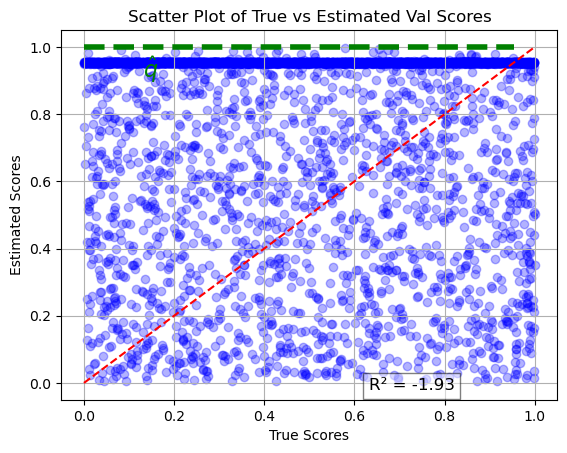

In [12]:
val_scores_est = np.concatenate([val_scores_above_est, val_scores_below_est], 0)
val_scores_true_ordered = np.concatenate([val_scores_true[above_val_inds], val_scores_true[below_val_inds]], 0)


import matplotlib.pyplot as plt
from sklearn.metrics import r2_score


plt.scatter(val_scores_true_ordered, val_scores_est, color='blue', alpha=0.3)
plt.title('Scatter Plot of True vs Estimated Val Scores')
r2 = r2_score(val_scores_true_ordered, val_scores_est)
plt.text(0.35, 0.1, f'R² = {r2:.2f}', transform=ax[0].transAxes, 
         fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))

plt.text(-0.2, 1.15, '$\hat{q}$', transform=ax[0].transAxes, 
         verticalalignment='top', color='green', fontsize=16, fontweight='bold')
plt.hlines(1, 0, baseline_qhat, 'g', linestyles='dashed', linewidth=4)

plt.xlabel('True Scores')
plt.ylabel('Estimated Scores')

plt.plot([0, 1], [0, 1], 'r--')
plt.grid(True)


# Results

In [13]:
# import torch
# from pprint import pprint
# pprint(torch.hub.list("chenyaofo/pytorch-cifar-models", force_reload=True))

In [14]:
import pandas as pd

metrics_list = [baseline_mets, ours_mets, ours_two_groups_mets]

df = pd.DataFrame(columns=['Method', 'Size', 'Coverage'])
df.loc[0] = ['Baseline', baseline_mets['size'], baseline_mets['coverage']]
df.loc[1] = ['Baseline groups', baseline_groups_mets['size'], baseline_groups_mets['coverage']]
df.loc[2] = ['Ours', ours_mets['size'], ours_mets['coverage']]
df.loc[3] = ['Ours groups', ours_two_groups_mets['size'], ours_two_groups_mets['coverage']]
print(df)

            Method     Size  Coverage
0         Baseline  10.9112    0.9596
1  Baseline groups  10.6330    0.9596
2             Ours   8.3052    0.9474
3      Ours groups  10.7076    0.9600
